In [7]:
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import sklearn
import pandas as pd
import sys
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
from torchvision import datasets
from torchvision.transforms import Normalize
from torchvision.transforms import ToTensor
import os

print(sys.version_info)
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)

sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.3
pandas 3.0.1
sklearn 1.8.0
torch 2.10.0+cu128
cuda:0


# 加载数据

In [8]:
train_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)
test_ds = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor()
)

#计算均值和方差
def cal_mean_std(ds):
    mean = 0.
    std = 0.
    for image_input, _ in ds:
        # 遍历每张图片, image.shape=[1,28,28]
        mean += image_input.mean(dim=(1, 2))
        # 计算每张图片的均值, dim=(1, 2)表示每张图片的宽高共同求均值
        std += image_input.std(dim=(1, 2))
    mean /= len(ds)
    std /= len(ds)
    return mean, std
    # 单通道的图, mean结果是0维张量 
    # 如果是多通道的图, mean是1维张量, 传入Normalize时最好使用tolist


mean_train, std_train = cal_mean_std(train_ds)
transforms=nn.Sequential(Normalize(mean_train, std_train))

In [9]:
# 数据加载器, 将其进行分批和其他处理
train_ld = torch.utils.data.DataLoader(train_ds, batch_size=32, shuffle=True)  
#batch_size批大小, shuffle洗牌, 这是为了避免局部最优解
val_ld = torch.utils.data.DataLoader(test_ds, batch_size=32, shuffle=False)
# 验证集不需要打乱

## 定义模型
在深度神经网络的基础上, 加上了Batch Normalization, 批归一化  
其过程是设定学习参数γ(缩放因子)和β(移位因子)  
对每批的每个特征计算一次均值与方差, 对该批的每一列特征进行标准化(根号内将方差加上一个小数避免除0, 或方差过小导致数值爆炸), 在列上做标准化, 而不是将batch的所有数字一起算  
之后将标准化后的结果乘以γ, 加上β. 从而远离导数饱和区(梯度消失区), 避免分布数据偏移  
既把数据拉近了, 也避免分布过于靠近0(否则ReLu有一半结果变成0, sigmoid变成几乎线性  
分布数据偏移是指"Internal Covariate Shift(内部协变量偏移)", 前一层的参数更新会导致后一层输入分布变化, 上游微小的改变会被累积放大, 所以每层之间要"拉回稳定状态"

使梯度更稳定, 收敛更快, 可用较大学习率

In [21]:
class NeuralNetwork(nn.Module):
    def __init__(self, layers_num=2):
        super().__init__()
        self.transforms = transforms 
        # 预处理层，标准化
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28 * 28, 100),
            nn.BatchNorm1d(100),
            # 对每个特征维度做批归一化
            # 如上所述, 要避免激活函数的一些弊端, 所以批归一化层在隐藏层和激活函数层间
            nn.ReLU(),
        )
        # 添加第一层
        for i in range(1, layers_num):
            self.linear_relu_stack.add_module(f"Linear_{i}", nn.Linear(100, 100))
            self.linear_relu_stack.add_module(f"batchnorm_{i}", nn.BatchNorm1d(100)) 
            self.linear_relu_stack.add_module(f"relu", nn.ReLU())
            # 加上layer_num个全连接层和激活函数
        self.linear_relu_stack.add_module("Output Layer", nn.Linear(100, 10))
        # 添加输出层
        
        self.init_weights()
        # 初始化权重
        
    def init_weights(self):
        # 使用 xavier 均匀分布来初始化全连接层的权重
        for m in self.modules():
            # print(m)
            # print('-'*50)
            if isinstance(m, nn.Linear):
                # isinstance, 判断m是否为nn.Linear
                nn.init.xavier_uniform_(m.weight) 
                # xavier 均匀分布初始化权重, 公式是 6/fan_in + fan_out
                nn.init.zeros_(m.bias) 
                # 全零初始化偏置项
    def forward(self, x):
        x = self.transforms(x) 
        # 标准化
        # x.shape [batch size, 1, 28, 28]
        x = self.flatten(x)  
        # flattened x.shape [batch size, 28 * 28]
        logits = self.linear_relu_stack(x)
        # logits.shape [batch size, 10]
        return logits
total=0
# 设置层数为20层, 计算总参数量
for idx, (key, value) in enumerate(NeuralNetwork(20).named_parameters()):
    # named_parameters()返回一个迭代器, 里面的每一项是(参数名, 参数)
    # enumerate()同时得到索引和元素
    print("{} {:<40}\t{:^10}".format(idx, key, np.prod(value.shape)))
    # {}默认格式, {:<40}左对齐, 宽度40, {:^10}居中对齐, 宽度10, ':'表示后面是格式说明
    total+=np.prod(value.shape)
    # value是一个tensor, prod将ndarray里的每个元素相乘(product)
    # 累加起来得到总参数量
total 

0 linear_relu_stack.0.weight              	  78400   
1 linear_relu_stack.0.bias                	   100    
2 linear_relu_stack.1.weight              	   100    
3 linear_relu_stack.1.bias                	   100    
4 linear_relu_stack.Linear_1.weight       	  10000   
5 linear_relu_stack.Linear_1.bias         	   100    
6 linear_relu_stack.batchnorm_1.weight    	   100    
7 linear_relu_stack.batchnorm_1.bias      	   100    
8 linear_relu_stack.Linear_2.weight       	  10000   
9 linear_relu_stack.Linear_2.bias         	   100    
10 linear_relu_stack.batchnorm_2.weight    	   100    
11 linear_relu_stack.batchnorm_2.bias      	   100    
12 linear_relu_stack.Linear_3.weight       	  10000   
13 linear_relu_stack.Linear_3.bias         	   100    
14 linear_relu_stack.batchnorm_3.weight    	   100    
15 linear_relu_stack.batchnorm_3.bias      	   100    
16 linear_relu_stack.Linear_4.weight       	  10000   
17 linear_relu_stack.Linear_4.bias         	   100    
18 linear_relu_stack

np.int64(275410)

In [11]:
class EarlyStopCallback:
    def __init__(self, patience=5, min_delta=0.01):
        """

        Args:
            patience (int, optional): Number of epochs with no improvement after which training will be stopped. Defaults to 5.
            min_delta (float, optional): Minimum change in the monitored quantity to qualify as an improvement, i.e. an absolute 
                change of less than min_delta, will count as no improvement. Defaults to 0.01.
        """
        self.patience = patience 
        # 多少个step没有提升min_delta就停止训练
        self.min_delta = min_delta 
        # 最小的提升幅度
        self.best_metric = -1
        self.counter = 0 
        # 计数器, 记录多少个step没有提升
        
    def __call__(self, metric):
        if metric >= self.best_metric + self.min_delta:
            self.best_metric = metric
            # 将当前算子作为最佳算子
            self.counter = 0
        else: 
            self.counter += 1
            # 假如这一步没有更优, 则计数器加一
            
    @property 
    # property装饰器指将方法变成属性
    def early_stop(self):
        return self.counter >= self.patience

In [12]:
class SaveCheckpointsCallback:
    def __init__(self, save_dir, save_epoch=1, save_step=500, save_best_only=True):
        """
        Save checkpoints each save_epoch epoch. 
        We save checkpoint by epoch in this implementation.
        Usually, training scripts with pytorch evaluating model and save checkpoint by step.

        Args:
            save_dir (str): dir to save checkpoint
            save_epoch (int, optional): the frequency to save checkpoint. Defaults to 1.
            save_best_only (bool, optional): If True, only save the best model or save each model at every epoch.
        """
        self.save_dir = save_dir # 保存路径
        self.save_step = save_step # 保存步数
        self.save_best_only = save_best_only # 是否只保存最好的模型
        self.best_metrics = -1 # 最好的指标, 指标不可能为负数, 所以初始化为-1
        self.save_epoch = save_epoch
        # mkdir
        if not os.path.exists(self.save_dir): 
            # 如果不存在保存路径, 则创建
            os.mkdir(self.save_dir)
        
    def __call__(self, step, state_dict, metric=None):
        if step % self.save_step > 0: 
            # 每隔save_step步保存一次
            return
        
        if self.save_best_only:
            assert metric is not None,'metric is not None' 
            # 必须传入metric
            if metric >= self.best_metrics:
                # save checkpoints
                torch.save(state_dict, os.path.join(self.save_dir, "best_dnn.ckpt")) 
                # os.path.join表示路径拼接, 相当于save_dir+"best.ckpt"
                # 保存最好的模型, 覆盖之前的模型
                # 不保存step, 只保存state_dict, 即模型参数, 不保存优化器参数
                self.best_metrics = metric
        else:
            torch.save(state_dict, os.path.join(self.save_dir, f"{step}.ckpt")) 
            # 保存每个step的模型, 不覆盖之前的模型
            # 保存step, 保存state_dict, 即模型参数, 不保存优化器参数

In [13]:
network = NeuralNetwork(20)
network.to(device)
# 1. 定义损失函数
loss_fct = nn.CrossEntropyLoss()
# 输出时将logits经过softmax, 和转换为one-hot编码的标签值计算交叉熵损失
# 得到的是标量(0维张量)

# 2. 定义优化器 采用SGD(随机梯度下降, stochastic gradient descent)
opt = torch.optim.SGD(network.parameters(), lr=0.001, momentum=0.9)
# lr学习率, momentum动量

In [14]:
for name, param in network.named_parameters(): 
    # 打印模型参数
    print(name)
    print(param.shape)

linear_relu_stack.0.weight
torch.Size([100, 784])
linear_relu_stack.0.bias
torch.Size([100])
linear_relu_stack.1.weight
torch.Size([100])
linear_relu_stack.1.bias
torch.Size([100])
linear_relu_stack.Linear_1.weight
torch.Size([100, 100])
linear_relu_stack.Linear_1.bias
torch.Size([100])
linear_relu_stack.batchnorm_1.weight
torch.Size([100])
linear_relu_stack.batchnorm_1.bias
torch.Size([100])
linear_relu_stack.Linear_2.weight
torch.Size([100, 100])
linear_relu_stack.Linear_2.bias
torch.Size([100])
linear_relu_stack.batchnorm_2.weight
torch.Size([100])
linear_relu_stack.batchnorm_2.bias
torch.Size([100])
linear_relu_stack.Linear_3.weight
torch.Size([100, 100])
linear_relu_stack.Linear_3.bias
torch.Size([100])
linear_relu_stack.batchnorm_3.weight
torch.Size([100])
linear_relu_stack.batchnorm_3.bias
torch.Size([100])
linear_relu_stack.Linear_4.weight
torch.Size([100, 100])
linear_relu_stack.Linear_4.bias
torch.Size([100])
linear_relu_stack.batchnorm_4.weight
torch.Size([100])
linear_relu_

In [15]:
from sklearn.metrics import accuracy_score


# 3.编写评估函数
@torch.no_grad()
# 装饰器, 禁止反向传播, 节省内存
def evaluating(model, dataloader, loss_function):
    loss_list = []
    # 记录损失
    pred_list = []
    # 记录预测
    label_list = []
    # 记录标签
    for data, label in dataloader:
        # 一共10000/32=312个batch
        data = data.to(device)
        # 把tensor放入GPU
        label = label.to(device)
        # 转到GPU
        logits = model(data)
        # 前向计算
        loss = loss_function(logits, label)
        # 使用loss_function计算本batch的损失, 得到的实际上是一个张量
        loss_list.append(loss.item())
        # 记录损失, item把tensor转换为数值, 注意item只能处理0维张量  

        pred = logits.argmax(axis=-1)
        # 验证集预测, argmax返回最大值索引数组
        # logits是一个(32, 10)数组, 求出的pred是一个(32, )数组,
        # 即每个样本使用十个标签概率的最大值的索引作为预测值
        pred_list.extend(pred.cpu().numpy().tolist())
        # numpy()将PyTorch张量转换为NumPy数组。只有当张量在CPU上时, 这个转换才是合法的
        label_list.extend(label.cpu().numpy().tolist())

    acc = accuracy_score(label_list, pred_list)
    # 计算准确率
    return np.mean(loss_list), acc

In [16]:
save_ckpt_callback = SaveCheckpointsCallback("checkpoints", save_best_only=True)
early_stop_callback = EarlyStopCallback(patience=5)

In [17]:
# 4.训练

def training(model, train_loader, val_loader, epoch, loss_function,
             optimizer,
             tensorboard=None,
             save_ckpt=None,
             early_stop=None,
             eval_step=500):
    """
    训练函数
    :param model: 模型
    :param train_loader: 训练数据集
    :param val_loader: 验证数据集
    :param epoch: 训练轮数
    :param loss_function: 损失函数
    :param optimizer: 优化器
    :param tensorboard: 可视化回调函数
    :param save_ckpt: 保存回调函数
    :param early_stop: 早停回调函数
    :param eval_step: 每训练多少batch对验证集进行评估
    :return: dict
    """
    record_dict = {
        "train": [],
        "val": []
    }
    # 存储训练集和测试集的损失和准确率
    global_step = 0
    # 记录总步数, 在进度条中使用
    model.train()
    # 进入训练模式
    # 对于一些特定层很重要：
    # Dropout → 在训练阶段才会随机丢弃神经元
    # BatchNorm → 使用 batch 的均值和方差
    with (tqdm(total=epoch * len(train_loader)) as pbar): 
        # with是上下文管理器, 保证进度条结束后自动关闭
        # 进度条一共 len(train_loader)*epoch 步
        for epoch_id in range(epoch): 
            # 训练epoch次
            for data, label in train_loader: 
                # 每次迭代得到一个batch
                # 执行次数是60000/32=1875
                data = data.to(device) 
                # datas尺寸是[batch_size,1,28,28], 转到GPU
                label = label.to(device) 
                # labels尺寸是[batch_size], 转到GPU
                optimizer.zero_grad()
                # 梯度清空, PyTorch会累加梯度, 要避免上一batch的梯度影响后面
                logits = model(data)
                # 正向计算, 得到未经过softmax的输出
                loss = loss_function(logits, label)
                # 计算损失
                loss.backward()
                # 梯度回传, loss.backward()会计算梯度, loss对模型参数(权重和偏置)求导
                optimizer.step()
                # 调整优化器, 改变学习率(如果使用了学习率调度器), 更新模型参数和一些其他值
                # 梯度计算并存储在模型参数的 .grad 属性中
                # 优化器使用这些存储的梯度来更新模型参数

                pred = logits.argmax(axis=-1) 
                # 对训练集预测
                acc = accuracy_score(label.cpu().numpy(), pred.cpu().numpy()) 
                # 每个batch计算准确率
                loss = loss.cpu().item()
                # loss这一0维张量转换为数值
                record_dict["train"].append({
                    "loss": loss, "acc": acc, "step": global_step
                }) 
                # 记录训练集信息, 每一步的损失, 准确率, 步数
                
                if global_step % eval_step == 0:
                    model.eval() 
                    # 进入评估模式
                    # Dropout 停用
                    # BatchNorm 使用训练时统计值
                    val_loss, val_acc = evaluating(model, val_loader, 
                                                   loss_function)
                    record_dict["val"].append({
                        "loss": val_loss, "acc": val_acc, "step": global_step
                    })
                    model.train() 
                    # 进入训练模式
                    
                    # 1. 使用tensorboard可视化
                    if tensorboard is not None:
                        tensorboard(
                            global_step, 
                            loss=loss, val_loss=val_loss,
                            acc=acc, val_acc=val_acc,
                            lr=optimizer.param_groups[0]["lr"], # 取出当前学习率
                            )
                    
                    # 2. 保存模型权重save model checkpoint
                    if save_ckpt is not None:
                        save_ckpt(global_step, model.state_dict(), metric=val_acc) 
                        # 保存最好的模型, 覆盖之前的模型
                        # 保存step, 保存state_dict,通过metric判断是否保存最好的模型

                    # 3. 早停Early Stop
                    if early_stop is not None:
                        early_stop(val_acc) 
                        # 验证集准确率不再提升, 则停止训练
                        if early_stop.early_stop:
                            # 注意之前有property装饰器, 将方法作为属性计算
                            # 属性的值就是方法的返回值
                            print(f"Early stop at epoch {epoch_id} / global_step {global_step}")
                            return record_dict

                global_step += 1 
                # 全局步数加1
                pbar.update(1) 
                # 更新进度条
                pbar.set_postfix({"epoch": epoch_id}) 
                # 设置进度条显示信息
        
    return record_dict

In [18]:
record=training(network, train_ld, val_ld, epoch=100, loss_function=loss_fct, optimizer=opt, tensorboard=None, save_ckpt=save_ckpt_callback, early_stop=early_stop_callback, eval_step=1000)

  0%|          | 0/187500 [00:00<?, ?it/s]

Early stop at epoch 11 / global_step 22000


In [19]:
print(pd.DataFrame(record["train"]).set_index("step")[-50:])

           loss      acc
step                    
21951  0.224479  0.90625
21952  0.378606  0.90625
21953  0.435324  0.87500
21954  0.303756  0.87500
21955  0.182509  0.93750
21956  0.238087  0.87500
21957  0.383989  0.81250
21958  0.434605  0.81250
21959  0.206618  0.93750
21960  0.195884  0.93750
21961  0.146062  0.96875
21962  0.264990  0.90625
21963  0.215875  0.93750
21964  0.470029  0.84375
21965  0.092842  0.96875
21966  0.184165  0.93750
21967  0.376969  0.78125
21968  0.172886  0.90625
21969  0.230289  0.90625
21970  0.143011  0.96875
21971  0.268220  0.90625
21972  0.493908  0.81250
21973  0.348128  0.81250
21974  0.290615  0.93750
21975  0.471147  0.90625
21976  0.231247  0.93750
21977  0.362659  0.84375
21978  0.217637  0.93750
21979  0.250496  0.90625
21980  0.140235  0.96875
21981  0.109610  0.96875
21982  0.218309  0.87500
21983  0.331518  0.90625
21984  0.548513  0.78125
21985  0.222524  0.96875
21986  0.174359  0.96875
21987  0.266011  0.87500
21988  0.099419  1.00000


Index(['loss', 'acc'], dtype='str')
step
0        0.09375
500      0.81250
1000     0.81250
1500     0.87500
2000     0.87500
2500     0.87500
3000     0.90625
3500     0.90625
4000     0.84375
4500     0.81250
5000     0.75000
5500     0.81250
6000     0.75000
6500     0.87500
7000     0.93750
7500     0.93750
8000     0.90625
8500     0.90625
9000     0.84375
9500     0.81250
10000    0.71875
10500    0.90625
11000    0.93750
11500    0.81250
12000    0.93750
12500    0.84375
13000    0.90625
13500    0.90625
14000    0.81250
14500    0.90625
15000    0.93750
15500    0.87500
16000    0.84375
16500    0.84375
17000    0.93750
17500    0.87500
18000    0.96875
18500    0.87500
19000    0.93750
19500    0.90625
20000    0.81250
20500    0.90625
21000    0.87500
21500    0.78125
22000    0.93750
Name: acc, dtype: float64
step
0        0.068500
1000     0.843217
2000     0.858667
3000     0.867233
4000     0.877033
5000     0.883833
6000     0.886000
7000     0.888767
8000     0.885633
9

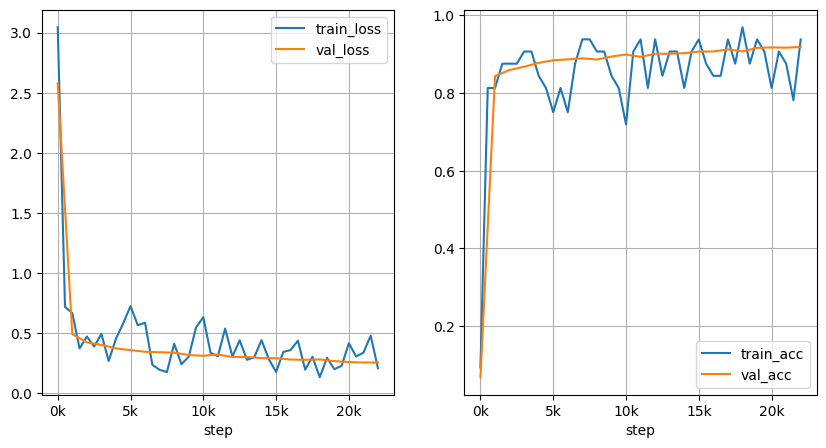

In [20]:
def plot_learning_curves(record_dict, sample_step=500):
    train_df = pd.DataFrame(record_dict["train"]).set_index("step").iloc[::sample_step]
    # set_index将行索引设置成step, 每隔sample_step取一次
    val_df = pd.DataFrame(record_dict["val"]).set_index("step")
    last_step = train_df.index[-1]
    # 最后一步的步数
    print(train_df.columns)
    print(train_df['acc'])
    print(val_df['acc'])
    
    fig_num = len(train_df.columns)
    fig, axs = plt.subplots(1, fig_num, figsize=(5 * fig_num, 5))
    for index, item in enumerate(train_df.columns):
        # enumerate同时得到索引和值
        # index = 0, 1, item = 'loss', 'acc'
        # print(train_df[item].values)
        axs[index].plot(train_df.index, train_df[item], label=f"train_{item}")
        axs[index].plot(val_df.index, val_df[item], label=f"val_{item}")
        axs[index].grid()
        axs[index].legend()
        axs[index].set_xticks(range(0, train_df.index[-1], 5000)) 
        axs[index].set_xticklabels(map(lambda x: f"{int(x/1000)}k", range(0, last_step, 5000)))
        axs[index].set_xlabel("step")
    
    plt.show()

plot_learning_curves(record)